# Experiment No. 9

## Title
**To create an OpenCV-Python program to smooth a given RGB/Grayscale image by a Gaussian filter**

## Objective
To smooth both grayscale and RGB images using a Gaussian filter.

## Mathematical Theory
Gaussian smoothing reduces noise by using a weighted average of neighboring pixels, where the center pixels are given more importance.

A common $3 \times 3$ Gaussian filter is:

$$
\frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}
$$

For grayscale image:

$$
g(x,y)=\sum_{m=-1}^{1}\sum_{n=-1}^{1} w(m,n)\,f(x+m,y+n)
$$

For RGB image:

$$
g(x,y,c)=\sum_{m=-1}^{1}\sum_{n=-1}^{1} w(m,n)\,f(x+m,y+n,c)
$$

Where:

- $f(x,y)$ = input pixel value  
- $g(x,y)$ = output pixel value  
- $w(m,n)$ = Gaussian kernel coefficient  
- $c$ = color channel (Red, Green, Blue)

Gaussian filtering produces smoother results than average filtering while preserving more natural image appearance.

## Instruments / Requirements
- Computer or Laptop
- Python
- OpenCV
- NumPy
- Matplotlib
- Input image: `demo_image.jpg`

## Procedure
1. Read the image using OpenCV.
2. If the image is color, convert it from BGR to RGB format.
3. Define the Gaussian kernel.
4. Apply convolution on each $3 \times 3$ neighborhood.
5. For RGB image, apply the filter separately on each color channel.
6. Store the smoothed image.
7. Display the original and Gaussian smoothed images.

## Output
- Original image (Grayscale/RGB)
- Smoothed image by Gaussian filter

## Result
The Gaussian filtered image shows reduced noise and smoother intensity transitions. In RGB images, smoothing is performed on each channel separately.

## Conclusion
Gaussian filtering is an effective smoothing method that reduces noise while maintaining a more natural visual quality than simple average filtering.

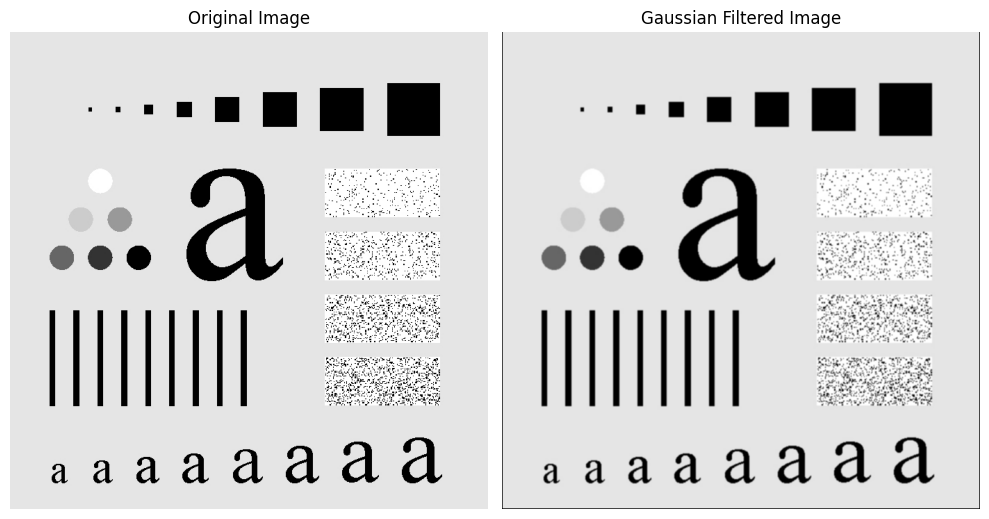

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('Exp9_Demo.jpg')

# Gaussian kernel
kernel = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]], dtype=np.float32) / 16

# Check grayscale or color
if len(img.shape) == 2:
    h, w = img.shape
    smoothed = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            s = 0
            for m in range(-1, 2):
                for n in range(-1, 2):
                    s += img[i + m, j + n] * kernel[m + 1, n + 1]
            smoothed[i, j] = int(s)

    display_img = img
    display_smooth = smoothed
    cmap = 'gray'

else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    smoothed = np.zeros((h, w, c), dtype=np.uint8)

    for k in range(c):
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                s = 0
                for m in range(-1, 2):
                    for n in range(-1, 2):
                        s += img[i + m, j + n, k] * kernel[m + 1, n + 1]
                smoothed[i, j, k] = int(s)

    display_img = img
    display_smooth = smoothed
    cmap = None

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(display_img, cmap=cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_smooth, cmap=cmap)
plt.title("Gaussian Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.savefig('Exp9_Output.png')  # Save full figure
plt.show()

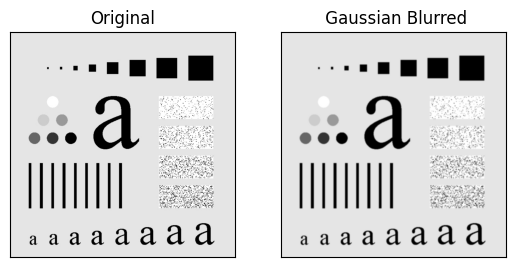

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Exp9_Demo.jpg')

blur = cv2.GaussianBlur(img,(5,5),0)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title(' Gaussian Blurred')
plt.xticks([]), plt.yticks([])
plt.show()